<a href="https://colab.research.google.com/github/saqer7/MLproject/blob/part3/part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 10 Association Rules:
  antecedents consequents  support  confidence      lift
0     (apple)     (bread)     0.34    0.666667  1.307190
1     (bread)     (apple)     0.34    0.666667  1.307190
2    (butter)     (apple)     0.33    0.622642  1.220866
3     (apple)    (butter)     0.33    0.647059  1.220866
4     (flour)     (apple)     0.39    0.650000  1.274510
5     (apple)     (flour)     0.39    0.764706  1.274510
6     (apple)    (orange)     0.32    0.627451  1.254902
7    (orange)     (apple)     0.32    0.640000  1.254902
8     (apple)     (sugar)     0.34    0.666667  1.234568
9     (sugar)     (apple)     0.34    0.629630  1.234568


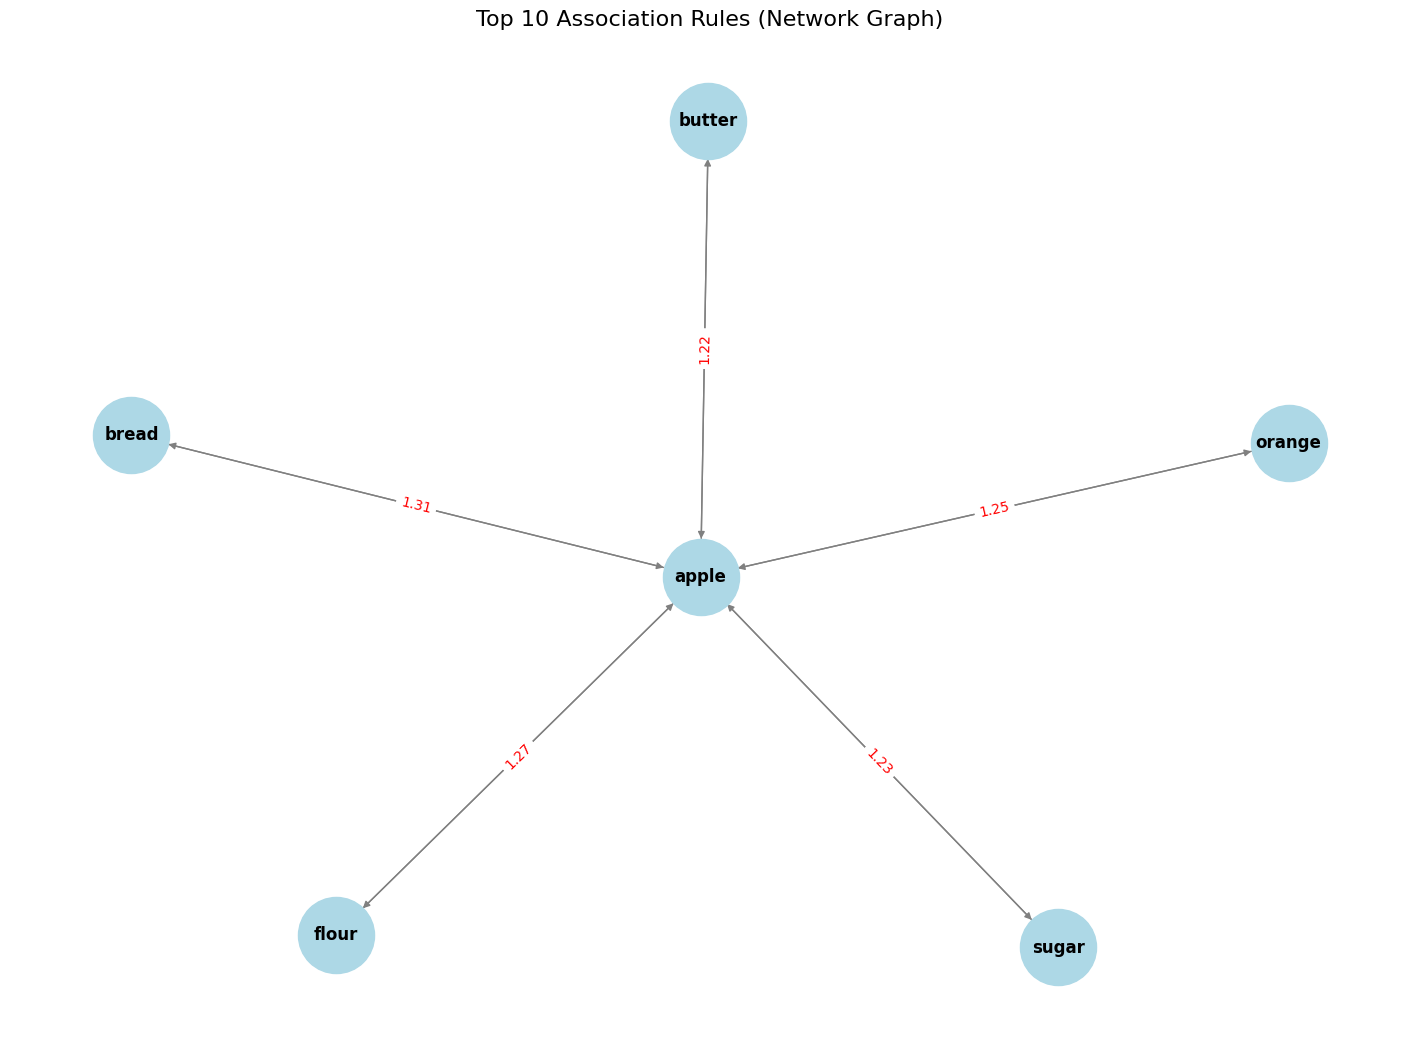

In [36]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Load and preprocess data
# Load dataset
groceries = []
with open("groceries.csv", "r") as f:
    for line in f:
        groceries.append(line.strip().split(","))

# Convert transaction lists into a matrix format
te = TransactionEncoder()
te_ary = te.fit(groceries).transform(groceries)
df = pd.DataFrame(te_ary, columns=te.columns_)

#Step 2: Apply Apriori algorithm to find frequent itemsets and association rules
#min_support=0.01
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

#min_lift=1.2
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Display top 10 rules
print("Top 10 Association Rules:")
print(rules.head(10)[["antecedents", "consequents", "support", "confidence", "lift"]])

# Step 3: Visualize results using network graphs
G = nx.DiGraph()
for _, rule in rules.head(10).iterrows():
    antecedents = ", ".join(rule["antecedents"])
    consequents = ", ".join(rule["consequents"])
    lift = round(rule["lift"], 2)
    G.add_edge(antecedents, consequents, weight=lift)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=12, font_weight="bold", edge_color="gray")

# Add edge labels (lift values)
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color="red")
plt.title("Top 10 Association Rules (Network Graph)", fontsize=16)
plt.show()

# Part 3: Association Rule Learning - Market Basket Analysis
## Insights from EDA
- **Frequent Items**: Apple (high support in multiple rules), bread, butter, flour, orange, sugar.

## Association Rules
- **Top 10 Rules**:
  - `{apple} -> {bread}`: Support = 0.34, Confidence = 0.67, Lift = 1.31
  - `{bread} -> {apple}`: Support = 0.34, Confidence = 0.67, Lift = 1.31
  - `{butter} -> {apple}`: Support = 0.33, Confidence = 0.62, Lift = 1.22
  - `{apple} -> {butter}`: Support = 0.33, Confidence = 0.65, Lift = 1.22
  - `{flour} -> {apple}`: Support = 0.39, Confidence = 0.65, Lift = 1.27
  - `{apple} -> {flour}`: Support = 0.39, Confidence = 0.76, Lift = 1.27
  - `{apple} -> {orange}`: Support = 0.32, Confidence = 0.63, Lift = 1.25
  - `{orange} -> {apple}`: Support = 0.32, Confidence = 0.64, Lift = 1.25
  - `{apple} -> {sugar}`: Support = 0.34, Confidence = 0.67, Lift = 1.23
  - `{sugar} -> {apple}`: Support = 0.34, Confidence = 0.63, Lift = 1.23

## Findings
- **Strongest Rule**: `{apple} -> {bread}` and `{bread} -> {apple}` with a lift of 1.31.
- **Insight**: Apples are frequently purchased with bread, butter, flour, orange, and sugar, indicating a strong association between these items.

## Visualization
- A network graph was created to visualize the top 10 association rules.
- Nodes represent items, and edges represent rules with lift values as labels.
